**<h1>AHJ Database: California Built Environment Personnel Mapping 2025**
#### Analysis 2.v2 =  Analysis 2 (filtered GCC data) + Geomap
<i>Any question regarding the notebook, please contact Robert Ford<br>
    Last Updated: 06/13/2025</i>
* AHJ Data: City and County level data sourced from Government Compensation California (GCC)
* Geo Data: Various open source databases including state and federal - ranging from census, ArcGIS, and other open sources
* Started development on 06/23/2025
* Finished Iteration on -06/23/2025-

In [ ]:
# Run once for loose matching
#%pip install rapidfuzz


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 29.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Import and load libs and packages
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import re
from rapidfuzz import process, fuzz


In [83]:
# Read Files and load data
ca_personnel = pd.read_excel("city_filtered_test_data.xlsx")
ca_geo_df = gpd.read_file("City_and_County_Boundary_Line_Changes_5487330134999085531.geojson")

In [ ]:
# Visual Checks of headers for personnel data and geodata 
#print(ca_personnel.head())
#print(ca_personnel.columns)


In [84]:
# Clean name for consistent joining
def clean_name(name):
    # Ensure that the name is not null and is a valid string
    name = str(name).strip().lower()
    if not name:  # If the name is empty after stripping, return a placeholder
        return ''
    # Just return the cleaned name (properly capitalized)
    return name.strip().title()

# Clean city names from 'EmployerName' column
ca_personnel['clean_city_name'] = ca_personnel['EmployerName'].apply(clean_name)

# Clean county names from 'EmployerCounty' column
ca_personnel['clean_county_name'] = ca_personnel['EmployerCounty'].apply(clean_name)

# Create personnel city dataframe (only cities are included)
personnel_cities = (
    ca_personnel[['clean_city_name']]  # Only keep 'clean_city_name'
    .drop_duplicates()
    .reset_index(drop=True)
)

# Create personnel county dataframe (only counties are included)
personnel_counties = (
    ca_personnel[['clean_county_name']]  # Only keep 'clean_county_name'
    .drop_duplicates()
    .reset_index(drop=True)
)

# Check if 'clean_city_name' is populated correctly
#personnel_cities.head()

# Check if 'clean_county_name' is populated correctly
#personnel_counties.head()


In [85]:
# Comment out if not needed

# Specify the city to exclude
excluded_city = "Los Angeles"
# Specify the county to exclude
excluded_county = "Los Angeles"

ca_personnel_filtered_city = ca_personnel[ca_personnel['clean_city_name'] != excluded_city]
ca_personnel_filtered_county = ca_personnel[ca_personnel['clean_county_name'] != excluded_county]


In [ ]:
# Aggregate personnel count by city
agg_city_counts = (
    ca_personnel.groupby('clean_city_name')
    .size()
    .reset_index(name='personnel_count_city')
)

# Check the aggregated personnel count for cities
#agg_city_counts


In [ ]:
# Recreate the aggregation for city personnel count after exclusion
agg_city_counts_filtered = (
    ca_personnel_filtered_city.groupby('clean_city_name')
    .size()
    .reset_index(name='personnel_count_city')
)
#agg_city_counts_filtered

In [ ]:
# Aggregate personnel count by county
agg_county_counts = (
    ca_personnel.groupby('clean_county_name')
    .size()
    .reset_index(name='personnel_count_county')
)

# Check the aggregated personnel count for counties
#agg_county_counts.head()


In [89]:
# Recreate the aggregation for county personnel count after exclusion
agg_county_counts_filtered = (
    ca_personnel_filtered_county.groupby('clean_county_name')
    .size()
    .reset_index(name='personnel_count_county')
)

In [90]:
# Merge aggregated personnel counts with city geodata
geo_city = ca_geo_df.copy()  # Assuming ca_geo_df is the geospatial data for both cities and counties
geo_city['clean_name'] = geo_city['CITY'].apply(lambda x: clean_name(str(x)))

# Merge the aggregated personnel count data into the geo dataframe for cities
geo_city = geo_city.merge(
    agg_city_counts,
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

# Fill NaN personnel counts with 0 (for cities without personnel data)
geo_city['personnel_count_city'] = geo_city['personnel_count_city'].fillna(0)


In [96]:
# Merge filtered with the city geospatial data
geo_city_filtered = ca_geo_df.copy()  # Assuming ca_geo_df is the geospatial data
geo_city_filtered['clean_name'] = geo_city_filtered['CITY'].apply(lambda x: clean_name(str(x)))

geo_city_filtered = geo_city_filtered.merge(
    agg_city_counts_filtered,
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

# Fill NaN personnel counts with 0 (for cities without personnel data)
geo_city_filtered['personnel_count_city'] = geo_city_filtered['personnel_count_city'].fillna(0)


In [92]:
# Merge aggregated personnel counts with county geodata
geo_county = ca_geo_df.copy()  # Assuming ca_geo_df has county data
geo_county['clean_name'] = geo_county['COUNTY'].apply(lambda x: clean_name(str(x)))

# Merge the aggregated personnel count data into the geo dataframe for counties
geo_county = geo_county.merge(
    agg_county_counts,
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)

# Fill NaN personnel counts with 0 (for counties without personnel data)
geo_county['personnel_count_county'] = geo_county['personnel_count_county'].fillna(0)


In [97]:
# Merge filtered with the county geospatial data
geo_county_filtered = ca_geo_df.copy()  # Assuming ca_geo_df is the geospatial data
geo_county_filtered['clean_name'] = geo_county_filtered['CITY'].apply(lambda x: clean_name(str(x)))

geo_county_filtered = geo_county_filtered.merge(
    agg_county_counts_filtered,
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)

# Fill NaN personnel counts with 0 (for cities without personnel data)
geo_county_filtered['personnel_count_county'] = geo_county_filtered['personnel_count_county'].fillna(0)


In [ ]:
# Plot the map showing personnel count by city
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

geo_city.plot(
    column='personnel_count_city',
    cmap='YlGnBu',  # Color map for city visualization
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Personnel Count by City", 'shrink': 0.5},
    ax=ax
)

ax.set_title("Personnel Count by City", fontsize=16)
ax.axis('off')  # Hide axis
plt.tight_layout()
plt.show()


In [ ]:
# Plot the map showing personnel count by city, excluding the specified city
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

geo_city_filtered.plot(
    column='personnel_count_city',
    cmap='YlGnBu',  # Color map for city visualization
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Personnel Count by City", 'shrink': 0.5},
    ax=ax
)

ax.set_title("Personnel Count by City (Excluding {})".format(excluded_city), fontsize=16)
ax.axis('off')  # Hide axis
plt.tight_layout()
plt.show()

In [ ]:
# Plot the map showing personnel count by county
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

geo_county.plot(
    column='personnel_count_county',
    cmap='OrRd',  # Color map for county visualization
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Personnel Count by County", 'shrink': 0.5},
    ax=ax
)

ax.set_title("Personnel Count by County", fontsize=16)
ax.axis('off')  # Hide axis
plt.tight_layout()
plt.show()


In [ ]:
# Plot the map showing personnel count by county, excluding the specified county
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

geo_county_filtered.plot(
    column='personnel_count_county',
    cmap='YlGnBu',  # Color map for county visualization
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Personnel Count by County", 'shrink': 0.5},
    ax=ax
)

ax.set_title("Personnel Count by County (Excluding {})".format(excluded_county), fontsize=16)
ax.axis('off')  # Hide axis
plt.tight_layout()
plt.show()

In [108]:
# Clean and prepare city GeoDataFrame
geo_city = ca_geo_df.copy()
geo_city['geo_city_name'] = geo_city['CITY'].astype(str)
geo_city['clean_name'] = geo_city['geo_city_name'].apply(clean_name)
geo_city['type'] = 'city'

# Clean the 'EmployerName' (city name) and extract unique city names
ca_personnel['clean_name'] = ca_personnel['EmployerName'].apply(clean_name)




In [ ]:
# Check the first few city names from personnel data
personnel_cities

In [115]:
# Use to clean up plot comment out if not needed
# Define the county you want to exclude (e.g., "Los Angeles")
exclude_county = "Los Angeles"  # or replace with the name of the county you want to exclude

# Filter out the county from the GeoDataFrame
geo_county_filtered = geo_county[geo_county['clean_name'] != clean_name(exclude_county)]


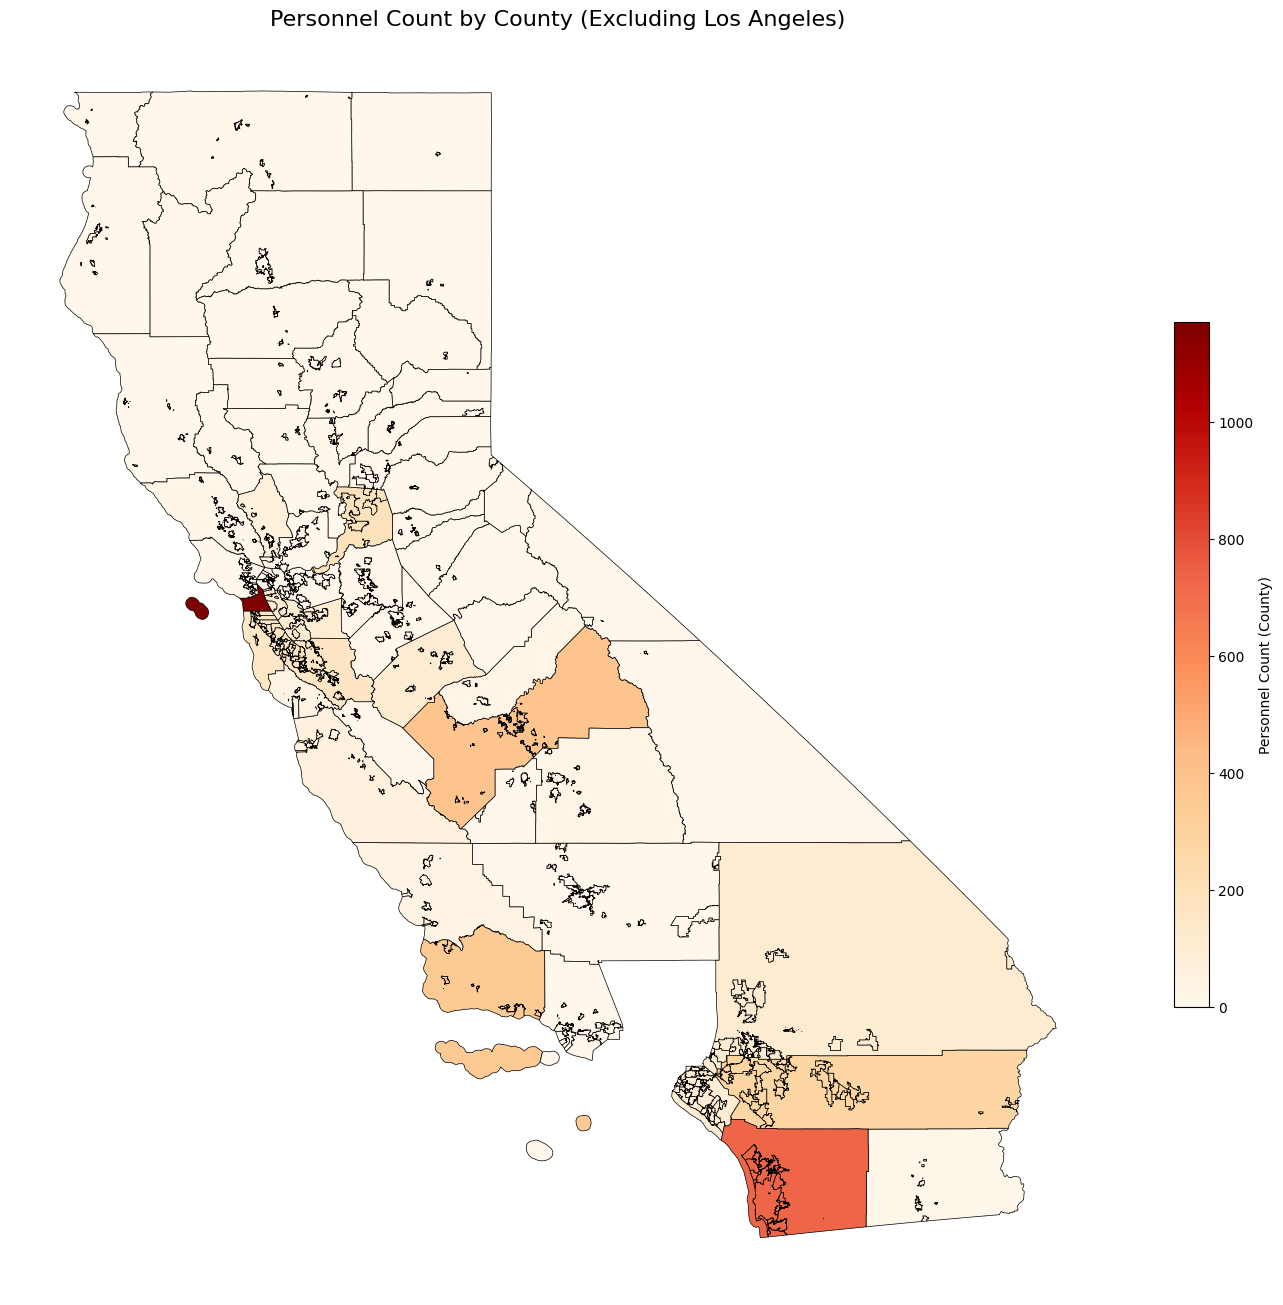

In [81]:
# For Filtered plots of county map without the excluded county
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

geo_county_filtered.plot(
    column='personnel_count',
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Personnel Count (County)", 'shrink': 0.5},
    ax=ax
)

ax.set_title(f"Personnel Count by County (Excluding {exclude_county})", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()
